In [1]:
import numpy as np
import json
import pandas as pd
from gensim.models import Word2Vec
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

class Word2VecEmbeddingExtractor:
    def __init__(self, model_path):
        """
        Initialize the embedding extractor with Word2Vec model path.
        """
        self.model = Word2Vec.load(model_path)
        print("Word2Vec model loaded successfully.")

    def extract_embeddings(self, words_labels):
        """
        Extract embeddings for each word and associate it with the provided label.
        """
        embeddings = []
        labels = []
        word_list = []

        for word, label in words_labels:
            if word in self.model.wv:
                embedding = self.model.wv[word]
                embeddings.append(embedding)
                labels.append(label)
                word_list.append(word)
            else:
                print(f"Word '{word}' not found in Word2Vec vocabulary. Skipping.")

        embeddings = np.array(embeddings)
        labels = np.array(labels)

        # Save embeddings and labels
        np.save("embeddings_word2vec.npy", embeddings)
        np.save("labels_word2vec.npy", labels)

        # Save word mapping as JSON
        word_mapping = {
            "index": list(range(len(word_list))),
            "word": word_list,
            "label": labels.tolist()
        }
        with open("word_mapping_word2vec.json", "w") as f:
            json.dump(word_mapping, f, indent=4)

        print(f"Saved {len(word_list)} embeddings with labels and word mappings.")

        return embeddings, labels, word_list

In [2]:

# Define the Word2Vec model path
model_path = "/Users/jonasklein/word2vec/trained_word2vec/word2vec_model"

# List of words and their labels
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0),
    ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0),
    ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1), ("grootmoeder", 0),
    ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0),
    ("jongen", 1), ("meisje", 0), ("jongetje", 1), ("meid", 0),
    ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0),
    ("peetvader", 1), ("peetmoeder", 0), ("bruidegom", 1), ("bruid", 0),
    ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1),
    ("dame", 0), ("kerel", 1), ("mister", 1), ("miss", 0),
    ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0),
    ("koning", 1), ("koningin", 0), ("lord", 1), ("lady", 0),
    ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0),
    ("mannelijk", 1), ("vrouwelijk", 0), ("gentleman", 1), ("gozer", 1),
    ("wijf", 0)
]

# Initialize the extractor
extractor = Word2VecEmbeddingExtractor(model_path)

# Process words and extract embeddings
embeddings, labels, word_list = extractor.extract_embeddings(words_labels)

# Verify shapes
print("Final embeddings shape:", embeddings.shape)
print("Final labels shape:", labels.shape)
print("Final word list length:", len(word_list))


Word2Vec model loaded successfully.
Saved 65 embeddings with labels and word mappings.
Final embeddings shape: (65, 200)
Final labels shape: (65,)
Final word list length: 65


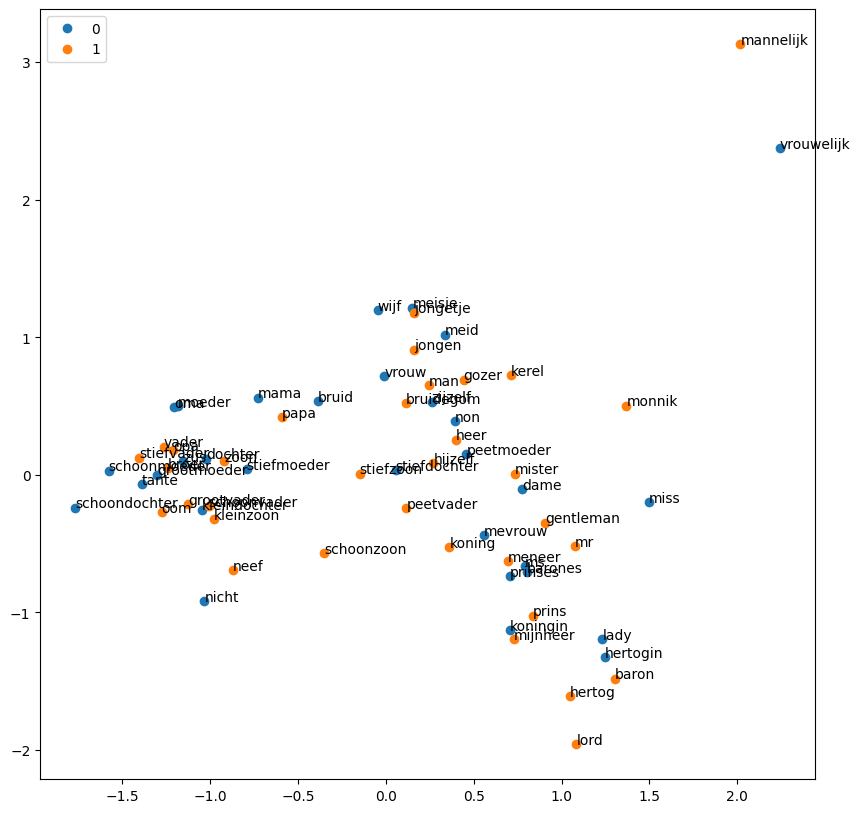

In [3]:
# Make a PCA plot of the embeddings
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings)

df = pd.DataFrame(pca_result, columns=["x", "y"])
df["label"] = labels
df["word"] = word_list

plt.figure(figsize=(10, 10))
groups = df.groupby("label")
for name, group in groups:
    plt.plot(group.x, group.y, marker="o", linestyle="", label=name)
    for i, txt in enumerate(group.word):
        plt.annotate(txt, (group.x.iloc[i], group.y.iloc[i]))

plt.legend()
plt.show()

Label distribution in the dataset:
label
1    34
0    31
Name: count, dtype: int64
Class balance: 0.9117647058823529
Percentage of majority class: 0.5230769230769231


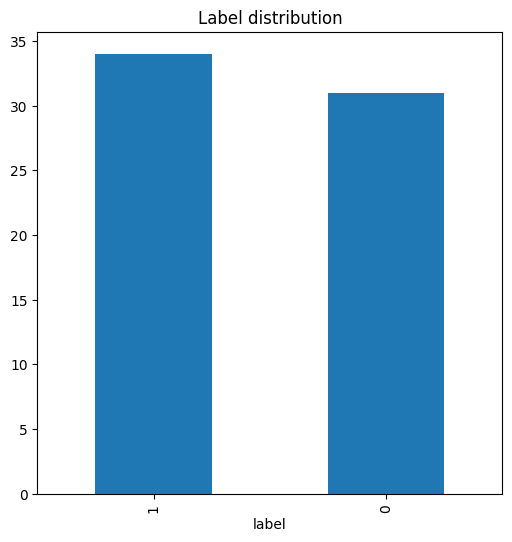

In [19]:
# Get label distribution in the dataset
label_distribution = df["label"].value_counts()
print("Label distribution in the dataset:")
print(label_distribution)
print("Class balance:", label_distribution[0] / label_distribution[1])
print("Percentage of majority class:", label_distribution[1] / label_distribution.sum())

# Visualize the label distribution
plt.figure(figsize=(6, 6))
label_distribution.plot(kind="bar", title="Label distribution")
plt.show()

In [4]:
# Load embeddings and labels
embeddings = np.load("embeddings_word2vec.npy")
labels = np.load("labels_word2vec.npy")

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=0.2, random_state=42, stratify=labels
)

# Initialize and train SVM classifier
svm_classifier = SVC(kernel='linear', random_state=42)
svm_classifier.fit(X_train, y_train)

# Predict on the test set
y_pred = svm_classifier.predict(X_test)

# Evaluate the classifier
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Female (0)", "Male (1)"]))


Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

  Female (0)       0.75      1.00      0.86         6
    Male (1)       1.00      0.71      0.83         7

    accuracy                           0.85        13
   macro avg       0.88      0.86      0.85        13
weighted avg       0.88      0.85      0.84        13



Label distribution in the test set:
1    7
0    6
Name: count, dtype: int64
Class balance: 0.8571428571428571
Percentage of majority class: 0.5384615384615384


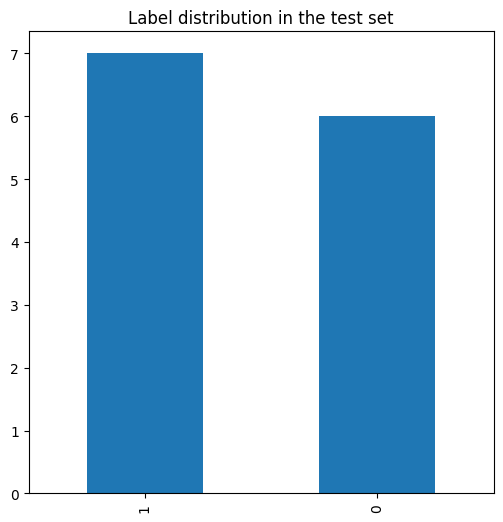

In [26]:
# Get label distribution in the test set
label_distribution = pd.Series(y_test).value_counts()
print("Label distribution in the test set:")
print(label_distribution)
print("Class balance:", label_distribution[0] / label_distribution[1])
print("Percentage of majority class:", label_distribution[1] / label_distribution.sum())

# Visualize the label distribution in the test set
plt.figure(figsize=(6, 6))
label_distribution.plot(kind="bar", title="Label distribution in the test set")
plt.show()

Class labels: [0 1]


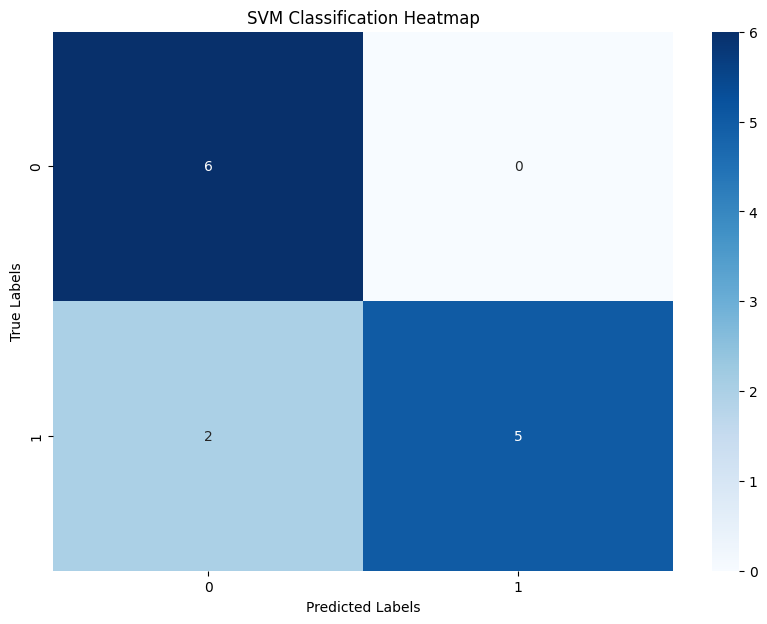

In [27]:
cm = confusion_matrix(y_test, y_pred)

# Unique class labels for annotation
class_labels = np.unique(labels)
print("Class labels:", class_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('SVM Classification Heatmap')
plt.show()

## Loop over all model checkpoints and saving the results to a file, including data augmentation

In [13]:
import os
import tempfile
import json
import re
import numpy as np
from azure.storage.blob import BlobServiceClient
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# === Word2Vec Embedding Extractor Class ===
class Word2VecEmbeddingExtractor:
    def __init__(self, model_path=None):
        self.model = None

    def load_model(self, model_path):
        self.model = Word2Vec.load(model_path)
        print(f"Loaded Word2Vec model from {model_path}")

    def extract_embeddings(self, words_labels, augment_factor=5, noise_std=0.05):
        embeddings, labels, words = [], [], []
        for word, label in words_labels:
            if word in self.model.wv:
                base_vec = self.model.wv[word]
                embeddings.append(base_vec)
                labels.append(label)
                words.append(word)

                # Generate augmented embeddings
                for _ in range(augment_factor):
                    noisy_vec = base_vec + np.random.normal(0, noise_std, base_vec.shape)
                    embeddings.append(noisy_vec)
                    labels.append(label)
                    words.append(f"{word}_aug")
            else:
                print(f"Skipping missing word: {word}")
        return np.array(embeddings), np.array(labels), words


# === List of (word, label) pairs ===
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0),
    ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0),
    ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1), ("grootmoeder", 0),
    ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0),
    ("jongen", 1), ("meisje", 0), ("jongetje", 1), ("meid", 0),
    ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0),
    ("peetvader", 1), ("peetmoeder", 0), ("bruidegom", 1), ("bruid", 0),
    ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1),
    ("dame", 0), ("kerel", 1), ("mister", 1), ("miss", 0),
    ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0),
    ("koning", 1), ("koningin", 0), ("lord", 1), ("lady", 0),
    ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0),
    ("mannelijk", 1), ("vrouwelijk", 0), ("gentleman", 1), ("gozer", 1),
    ("wijf", 0)
]

# === Azure Storage Setup ===
AZURE_CONN = os.getenv("SONAR_STORAGE_KEY")
if not AZURE_CONN:
    raise EnvironmentError("Please set the SONAR_STORAGE_KEY environment variable.")
CONTAINER = "results"
OUTPUT_DIR = "batch_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
blob_service = BlobServiceClient.from_connection_string(AZURE_CONN)
container = blob_service.get_container_client(CONTAINER)

# === Model Processing Function ===
def process_blob(blob_name):
    extractor = Word2VecEmbeddingExtractor()
    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        blob_client = container.get_blob_client(blob_name)
        downloader = blob_client.download_blob(timeout=300)
        with open(tmp.name, "wb") as f:
            for chunk in downloader.chunks():
                f.write(chunk)
        model_path = tmp.name

    extractor.load_model(model_path)
    embeddings, labels, words = extractor.extract_embeddings(words_labels, augment_factor=10, noise_std=0.05)
    os.unlink(model_path)

    # Group embeddings by base word
    word_to_indices = {}
    for i, word in enumerate(words):
        base_word = word.split("_aug")[0]
        word_to_indices.setdefault(base_word, []).append(i)

    base_words = list(word_to_indices.keys())
    train_words, test_words = train_test_split(base_words, test_size=0.2, random_state=42, stratify=[
        dict(words_labels)[w] for w in base_words
    ])

    train_indices = [i for w in train_words for i in word_to_indices[w]]
    test_indices = [i for w in test_words for i in word_to_indices[w]]

    X_train = embeddings[train_indices]
    y_train = labels[train_indices]
    X_test = embeddings[test_indices]
    y_test = labels[test_indices]

    svm = SVC(kernel="linear", random_state=42)
    svm.fit(X_train, y_train)
    preds = svm.predict(X_test)
    report = classification_report(y_test, preds, output_dict=True)
    return accuracy_score(y_test, preds), report

# === Batch Loop & JSON Output with Sorting ===
# Collect all model blob names
model_blobs = [blob.name for blob in container.list_blobs(name_starts_with="w2v/") if blob.name.endswith("model")]

# Function to extract (epoch, part) for sorting
def parse_key(name):
    match = re.search(r"epoch(\d+)_part(\d+)/model$", name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return float('inf'), float('inf')

# Sort by epoch then part
sorted_blobs = sorted(model_blobs, key=parse_key)

results = []
for blob_name in sorted_blobs:
    print(f"Processing {blob_name}...")
    acc, rep = process_blob(blob_name)
    results.append({"blob": blob_name, "accuracy": acc, "female": rep.get("0"), "male": rep.get("1")})
    print(f"Accuracy: {acc:.4f}")

# Save to JSON
json_path = os.path.join(OUTPUT_DIR, "model_comparison.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Completed! JSON saved at {json_path}")


Processing w2v/epoch1_part1/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpf1q2w8la
Accuracy: 0.3636
Processing w2v/epoch1_part2/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmposw2lbrj
Accuracy: 0.3846
Processing w2v/epoch1_part3/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpdz9v8kme
Accuracy: 0.4685
Processing w2v/epoch1_part4/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmptcgw4a9t
Accuracy: 0.4685
Processing w2v/epoch1_part5/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmp37lxacmx
Accuracy: 0.5245
Processing w2v/epoch1_part6/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpfizpgkgf
Accuracy: 0.5035
Processing w2v/epoch1_part7/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmp1ts_qu5t
Accuracy: 0.5524
Proces

Sorted data:
[{'blob': 'w2v/epoch1_part1/model', 'accuracy': 0.36363636363636365, 'female': {'precision': 0.3493975903614458, 'recall': 0.4393939393939394, 'f1-score': 0.38926174496644295, 'support': 66.0}, 'male': {'precision': 0.38333333333333336, 'recall': 0.2987012987012987, 'f1-score': 0.3357664233576642, 'support': 77.0}}, {'blob': 'w2v/epoch1_part2/model', 'accuracy': 0.38461538461538464, 'female': {'precision': 0.39, 'recall': 0.5909090909090909, 'f1-score': 0.46987951807228917, 'support': 66.0}, 'male': {'precision': 0.37209302325581395, 'recall': 0.2077922077922078, 'f1-score': 0.26666666666666666, 'support': 77.0}}, {'blob': 'w2v/epoch1_part3/model', 'accuracy': 0.46853146853146854, 'female': {'precision': 0.4431818181818182, 'recall': 0.5909090909090909, 'f1-score': 0.5064935064935064, 'support': 66.0}, 'male': {'precision': 0.509090909090909, 'recall': 0.36363636363636365, 'f1-score': 0.42424242424242425, 'support': 77.0}}, {'blob': 'w2v/epoch1_part4/model', 'accuracy': 0.

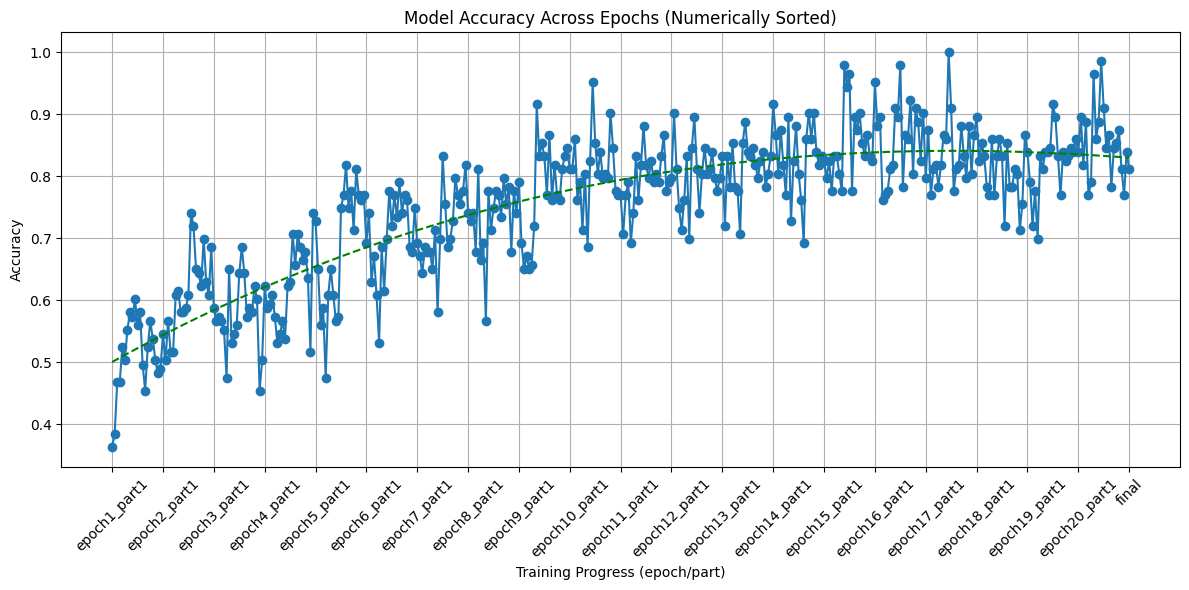

In [26]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('batch_results/model_comparison.json', 'r') as f:
    data = json.load(f)

def extract_epoch_part(blob):
    # Example: epoch10_part3 → (10, 3)
    match = re.search(r'epoch(\d+)_part(\d+)', blob)
    if match:
        return int(match.group(1)), int(match.group(2))
    return (float('inf'), float('inf'))  # push weird entries to the end

# Sort using numeric epoch/part
data_sorted = sorted(data, key=lambda x: extract_epoch_part(x['blob']))

print("Sorted data:")
print(data_sorted)

# Collect data
x = []
y = []

for entry in data_sorted:
    step_label = entry['blob'].split('/')[-2]  # e.g., 'epoch1_part3'
    x.append(step_label)
    y.append(entry['accuracy'])

x_labels = [entry['blob'].split('/')[-2] for entry in data_sorted]
x = list(range(len(x_labels)))
y = [entry['accuracy'] for entry in data_sorted]

plt.figure(figsize=(12, 6))
plt.plot(x, y, marker='o')
plt.plot(x, np.poly1d(np.polyfit(x, y, 3))(x), 'g--', label='Polynomial Trend')
N = 20
plt.xticks(ticks=range(0, len(x), N), labels=[x_labels[i] for i in range(0, len(x), N)], rotation=45)
plt.grid(True)
plt.xlabel("Training Progress (epoch/part)")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Across Epochs (Numerically Sorted)")
plt.tight_layout()
plt.show()

## Loop over all model checkpoints and saving the results to a file, including data augmentation, including k-fold cross validation

In [59]:
import os
import tempfile
import json
import re
import numpy as np
from azure.storage.blob import BlobServiceClient
from gensim.models import Word2Vec
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# === Word2Vec Embedding Extractor Class ===
class Word2VecEmbeddingExtractor:
    def __init__(self, model_path=None):
        self.model = None

    def load_model(self, model_path):
        self.model = Word2Vec.load(model_path)
        print(f"Loaded Word2Vec model from {model_path}")

    def extract_embeddings(self, words_labels, augment_factor=5, noise_std=0.05):
        embeddings, labels, words = [], [], []
        for word, label in words_labels:
            if word in self.model.wv:
                base_vec = self.model.wv[word]
                embeddings.append(base_vec)
                labels.append(label)
                words.append(word)

                for _ in range(augment_factor):
                    noisy_vec = base_vec + np.random.normal(0, noise_std, base_vec.shape)
                    embeddings.append(noisy_vec)
                    labels.append(label)
                    words.append(f"{word}_aug")
            else:
                print(f"Skipping missing word: {word}")
        return np.array(embeddings), np.array(labels), words

# === List of (word, label) pairs ===
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0),
    ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0),
    ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1), ("grootmoeder", 0),
    ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0),
    ("jongen", 1), ("meisje", 0), ("jongetje", 1), ("meid", 0),
    ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0),
    ("peetvader", 1), ("peetmoeder", 0), ("bruidegom", 1), ("bruid", 0),
    ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1),
    ("dame", 0), ("kerel", 1), ("mister", 1), ("miss", 0),
    ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0),
    ("koning", 1), ("koningin", 0), ("lord", 1), ("lady", 0),
    ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0),
    ("mannelijk", 1), ("vrouwelijk", 0), ("gentleman", 1), ("gozer", 1),
    ("wijf", 0)
]

# === Azure Storage Setup ===
AZURE_CONN = os.getenv("SONAR_STORAGE_KEY")
if not AZURE_CONN:
    raise EnvironmentError("Please set the SONAR_STORAGE_KEY environment variable.")
CONTAINER = "results"
OUTPUT_DIR = "w2v_svm_rbf_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
blob_service = BlobServiceClient.from_connection_string(AZURE_CONN)
container = blob_service.get_container_client(CONTAINER)

# === Model Processing Function with K-Fold CV ===
def process_blob_with_cv(blob_name, k=5):
    extractor = Word2VecEmbeddingExtractor()
    with tempfile.NamedTemporaryFile(delete=False) as tmp:
        blob_client = container.get_blob_client(blob_name)
        downloader = blob_client.download_blob(timeout=300)
        with open(tmp.name, "wb") as f:
            for chunk in downloader.chunks():
                f.write(chunk)
        model_path = tmp.name

    extractor.load_model(model_path)
    embeddings, labels, words = extractor.extract_embeddings(words_labels, augment_factor=10, noise_std=0.05)
    os.unlink(model_path)

    # Group embeddings by base word
    word_to_indices = {}
    for i, word in enumerate(words):
        base_word = word.split("_aug")[0]
        word_to_indices.setdefault(base_word, []).append(i)

    base_words = list(word_to_indices.keys())
    y_base = np.array([dict(words_labels)[w] for w in base_words])
    groups = np.array(base_words)

    skf = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=42)

    all_preds = []
    all_true = []

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(base_words, y_base, groups)):
        train_words = [base_words[i] for i in train_idx]
        test_words = [base_words[i] for i in test_idx]

        train_indices = [i for w in train_words for i in word_to_indices[w]]
        test_indices = [i for w in test_words for i in word_to_indices[w]]

        X_train = embeddings[train_indices]
        y_train = labels[train_indices]
        X_test = embeddings[test_indices]
        y_test = labels[test_indices]

        svm = SVC(kernel="rbf", random_state=42)
        svm.fit(X_train, y_train)
        preds = svm.predict(X_test)

        all_preds.extend(preds)
        all_true.extend(y_test)

    accuracy = accuracy_score(all_true, all_preds)
    report = classification_report(all_true, all_preds, output_dict=True)
    return accuracy, report

# === Collect all model blob names ===
model_blobs = [blob.name for blob in container.list_blobs(name_starts_with="w2v/") if blob.name.endswith("model")]

# === Function to extract (epoch, part) for sorting ===
def parse_key(name):
    match = re.search(r"epoch(\d+)_part(\d+)/model$", name)
    if match:
        return int(match.group(1)), int(match.group(2))
    return float('inf'), float('inf')

sorted_blobs = sorted(model_blobs, key=parse_key)

# === Run batch processing with K-Fold ===
results = []
for blob_name in sorted_blobs:
    print(f"Processing {blob_name}...")
    acc, rep = process_blob_with_cv(blob_name, k=5)
    results.append({"blob": blob_name, "accuracy": acc, "female": rep.get("0"), "male": rep.get("1")})
    print(f"Accuracy: {acc:.4f}")

# === Save results to JSON ===
json_path = os.path.join(OUTPUT_DIR, "model_comparison.json")
with open(json_path, "w") as f:
    json.dump(results, f, indent=4)

print(f"Completed! JSON saved at {json_path}")


Processing w2v/epoch1_part1/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmp50dosqxr
Accuracy: 0.4573
Processing w2v/epoch1_part2/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpfrxw3bzl
Accuracy: 0.3958
Processing w2v/epoch1_part3/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpv1a6ix2q
Accuracy: 0.4056
Processing w2v/epoch1_part4/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmp55_minhm
Accuracy: 0.4182
Processing w2v/epoch1_part5/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmppo1ct6vx
Accuracy: 0.4406
Processing w2v/epoch1_part6/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmppy1y0ohy
Accuracy: 0.4601
Processing w2v/epoch1_part7/model...
Loaded Word2Vec model from /var/folders/yx/bp07d_fj08bd4h_x3m2q3bcr0000gp/T/tmpou84tkzt
Accuracy: 0.4014
Proces

Incomplete download: ('Connection broken: IncompleteRead(3669375 bytes read, 524929 more expected)', IncompleteRead(3669375 bytes read, 524929 more expected))
Unable to stream download: HTTPSConnectionPool(host='sonardcoi.blob.core.windows.net', port=443): Read timed out.


ConnectionError: HTTPSConnectionPool(host='sonardcoi.blob.core.windows.net', port=443): Read timed out.

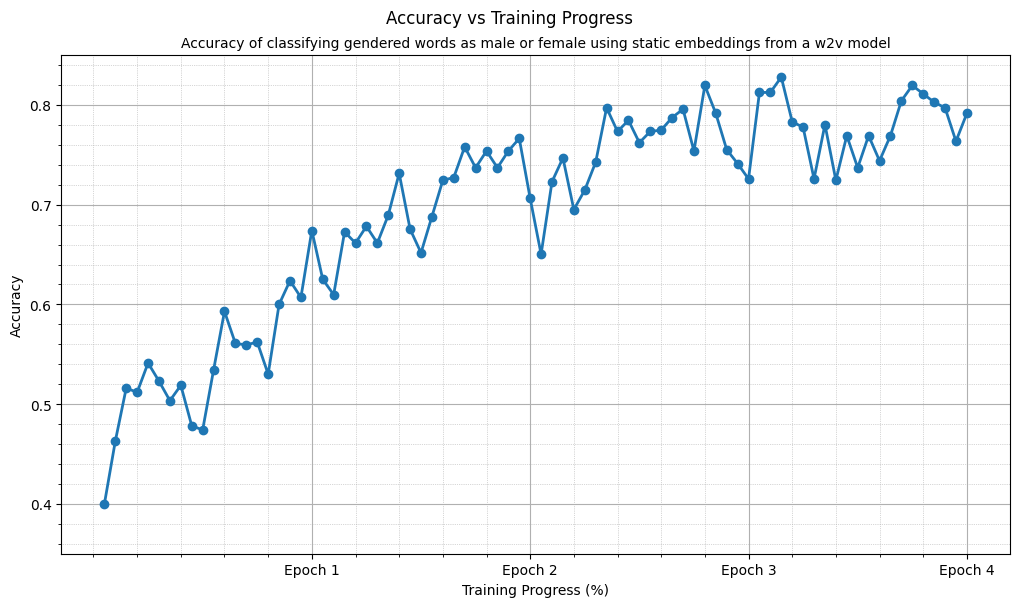

In [ ]:
import json
import matplotlib.pyplot as plt

# Path to your JSON file
file_path = "w2v_svm_results/model_comparison.json"

# Load the JSON data
with open(file_path, "r") as f:
    data = json.load(f)

data_subset = data[:80]

# Extract epoch progress and accuracies
progress = []
accuracies = []

for i, entry in enumerate(data_subset):
    part = i + 1
    epoch_percentage = part * 5  # each part is 5% of the epoch
    progress.append(epoch_percentage)
    accuracies.append(entry["accuracy"])

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(progress, accuracies, marker='o', linestyle='-', linewidth=2)
plt.suptitle("Accuracy vs Training Progress\n")
plt.title("Accuracy of classifying gendered words as male or female using static embeddings from a w2v model", fontsize=10)
plt.xlabel("Training Progress (%)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.xticks(
    ticks=[i * 20 * 5 for i in range(1, 5)],
    labels=[f"Epoch {i}" for i in range(1, 5)],
    rotation=0
)
plt.minorticks_on()
plt.grid(which='minor', linestyle=':', linewidth=0.5)
plt.ylim(0.35, 0.85)  # accuracy range
plt.tight_layout(pad=0.0)
plt.show()